# Example: IIRS L0 (DN) to L1 (Radiance)

This is a collection of example notebooks (work in progress) for working with IIRS data through iirspy. 

Warning: these notebook may not be kept up to date as the core functionality is still being reworked.

## Level 0 Raw data (Digital Number)

The IIRS raw data is given in DN and have file names containing `nri` (r is for raw), like `ch2_iir_nri_20220716T0450278161_d_img_hw1`.

Data can be downloaded from ISRO's ISSDC via the PRADAN site as a zipped file. 

## Automatic unzipping

The first time a zipped file is accessed, `iirspy` will unzip it and verify the checksum to ensure the file was not corrupted.

```python
>>> img = L0("20240520T1759268266", '/home/data/iirs')
>>> Extracting 20240520T1759268266 to /home/data/iirs
>>> Verifying unzipped image... Success!
```

## Data access

Data access is managed through `iirspy.L0(basename, directory)` as demonstrated below. Optionally, an extent (xmin, xmax, ymin, ymax) in pixels (x for Scan/crosstrack, y for Lines/alongtrack) can be given to read in a subset of the image.

/home/cjtu/projects/iirspy/iirspy/utils.py:1458: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


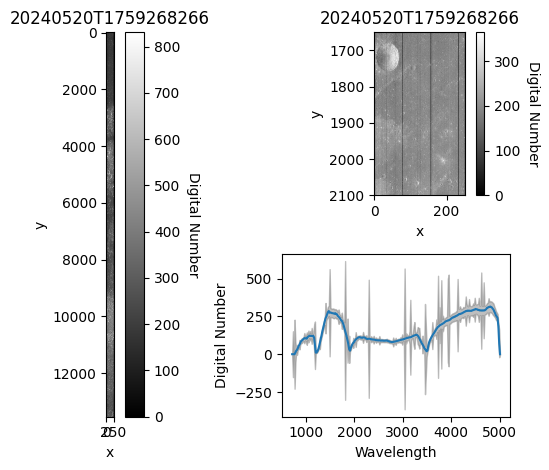

/home/cjtu/projects/iirspy/.venv/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/cjtu/projects/iirspy/.venv/lib/python3.10/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/cjtu/projects/iirspy/.venv/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/cjtu/projects/iirspy/.venv/lib/python3.10/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/cjtu/projects/iirspy/.venv/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/cjtu/projects/iirspy/.venv/lib/python

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt

from iirspy import L0

warnings.filterwarnings("ignore", category=RuntimeWarning, message="divide by zero")
warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in log")
# Define data paths and image ID
im = "20240520T1759268266"
ddir = Path("~/data/moon/ch2/iirs/").expanduser().as_posix()

# Load full L0 data
l0 = L0(im, ddir)

# Load L0 data with extent (None indicates full range)
extent = (0, None, 1650, 2100)  # (minx, maxx, miny, maxy)
l0_subset = L0(im, ddir, extent=extent)

# Plot L0 DN image, subset image, and subset spectra
plt.Figure(figsize=(12, 12))
plt.subplot(1, 2, 1)  # Full image strip on left
l0.plot(band=40, cmap="gray", ax=plt.gca())
plt.subplot(2, 2, 2)  # Subset image on top right
l0_subset.plot(band=40, cmap="gray", ax=plt.gca())
plt.subplot(2, 2, 4)  # Subset spectra on bottom right
l0_subset.plot_spectra(stdev_alpha=0.5, ax=plt.gca())
plt.tight_layout()

## Working with L0 data

In [2]:
print(l0.basename)
print(l0.extent)

# Data paths
print(l0.directory)
print(l0.qub)
print(l0.hdr)
print(l0.xml)
print(l0.lbr)
print(l0.oat)
print(l0.oath)
print(l0.spm)

20240520T1759268266
(0, 250, 0, 13543)
/home/cjtu/data/moon/ch2/iirs
/home/cjtu/data/moon/ch2/iirs/data/raw/20240520/ch2_iir_nri_20240520T1759268266_d_img_d18.qub
/home/cjtu/data/moon/ch2/iirs/data/raw/20240520/ch2_iir_nri_20240520T1759268266_d_img_d18.hdr
/home/cjtu/data/moon/ch2/iirs/data/raw/20240520/ch2_iir_nri_20240520T1759268266_d_img_d18.xml
/home/cjtu/data/moon/ch2/iirs/miscellaneous/raw/20240520/ch2_iir_nri_20240520T1759268266_d_img_d18.lbr
/home/cjtu/data/moon/ch2/iirs/miscellaneous/raw/20240520/ch2_iir_nri_20240520T1759268266_d_img_d18.oat
/home/cjtu/data/moon/ch2/iirs/miscellaneous/raw/20240520/ch2_iir_nri_20240520T1759268266_d_img_d18.oath
/home/cjtu/data/moon/ch2/iirs/miscellaneous/raw/20240520/ch2_iir_nri_20240520T1759268266_d_img_d18.spm


## Accessing metadata with pdr

In [3]:
# Some metadata is stored for easy access
print("\nAll metadata items in l0.metadata:")
for key, value in l0.metadata.items():
    print(f"  {key}: {value}")

# Get a specific metadata item
print("\nGet specific items with l0.metadata['key']:")
print("  l0.metadata['projection']:", l0.metadata["projection"])

# Other metadata from the PDS xml label can be queried with .metaget()
print("\nUse metaget to find other metadata:")
print("  Title:", l0.metaget("title"))


All metadata items in l0.metadata:
  job_id: IIRXXD18CHO2112502NNNN24141192354245_V2_1
  level0_dir_name: IIRXXD18CHO2112502NNNN24141192354245_V2_1
  imaging_orbit_number: 21124
  dumping_orbit_number: 21125
  line_exposure_duration: 53.060
  gain: g2
  exposure: e1
  exposure_duration: 1
  detector_temperature: 88.970
  tertiary_mirror_temperature: -39.677
  spectrometer_casing_temperature: -41.218
  dewar_vw_temperature: -47.352
  detector_pixel_width: 30
  focal_length: 74.999
  spacecraft_altitude: 126.22
  pixel_resolution: 100.97
  roll: -0.000396
  pitch: -0.086182
  yaw: 0.001277
  sun_azimuth: 272.296393
  sun_elevation: 56.147063
  solar_incidence: 33.852937
  projection: Selenographic
  area: Equatorial
  logical_identifier: urn:isro:isda:ch2_cho.iir:data_raw:ch2_iir_nri_20240520t1759268266_d_img_d18
  modification_date: 2019-12-02
  start_date_time: 2024-05-20T17:59:26.8266Z
  stop_date_time: 2024-05-20T18:11:25.3188Z
  file_size: 1733504000
  md5_checksum: 8ab2783dc4829b4

## Accessing the Image directly

In addition to plotting directly as shown above, you can access underlying xarray with `.img` and manipulate it as a dask datarray. The image is chunked with dask to lazily load and not consume too much ram until needed.

Note: operations applied to a dask image only occur when needed, so operations like `(l0.img * l0.img).sqrt()` may seem fast but are delayed until `.compute()` is explicitly called or the values are needed for plotting or saving to a file.

In [4]:
# Show the underlying xarray image data
l0.img

<xarray.DataArray 'band_data' (band: 256, y: 13543, x: 250)> Size: 3GB
dask.array<xarray-<this-array>, shape=(256, 13543, 250), dtype=float32, chunksize=(256, 781, 250), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 2kB 1 2 3 4 5 6 7 ... 250 251 252 253 254 255 256
  * x            (x) float64 2kB 0.5 1.5 2.5 3.5 4.5 ... 246.5 247.5 248.5 249.5
  * y            (y) float64 108kB 0.5 1.5 2.5 ... 1.354e+04 1.354e+04 1.354e+04
    spatial_ref  int64 8B ...
    wl           (band) float64 2kB dask.array<chunksize=(256,), meta=np.ndarray>
Attributes:
    samples:        250
    lines:          13543
    bands:          256
    header_offset:  0
    file_type:      ENVI Standard
    data_type:      2
    interleave:     bsq
    byte_order:     0
    name:           Digital Number
    units:

## Calibrate L0 data to L1 radiance

The IIRS L0->L1 calibration procedure involves applying the provided gain and offset calibration files to the DN to convert to radiance units.

Note: some smoothing and postprocessing steps conducted on the the released L1 data are not implemented here.

In [5]:
help(l0.calibrate)

Help on method calibrate in module iirspy.iirs:

calibrate(*args, **kwargs) method of iirspy.iirs.L0 instance
    Calibrate to L1 radiance using ISSDC calibration files if they exist.



<Axes: title={'center': '20240520T1759268266'}, xlabel='x', ylabel='y'>

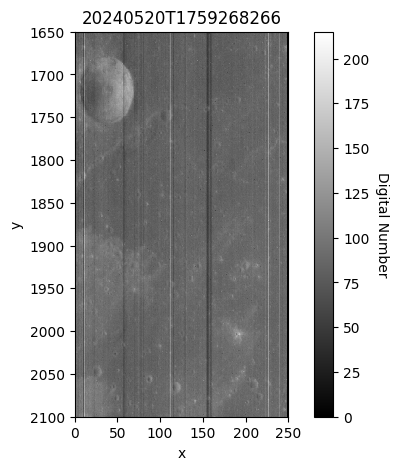

In [6]:
l0_subset.plot()

/home/cjtu/projects/iirspy/iirspy/utils.py:1458: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


(0.0, 20.0)

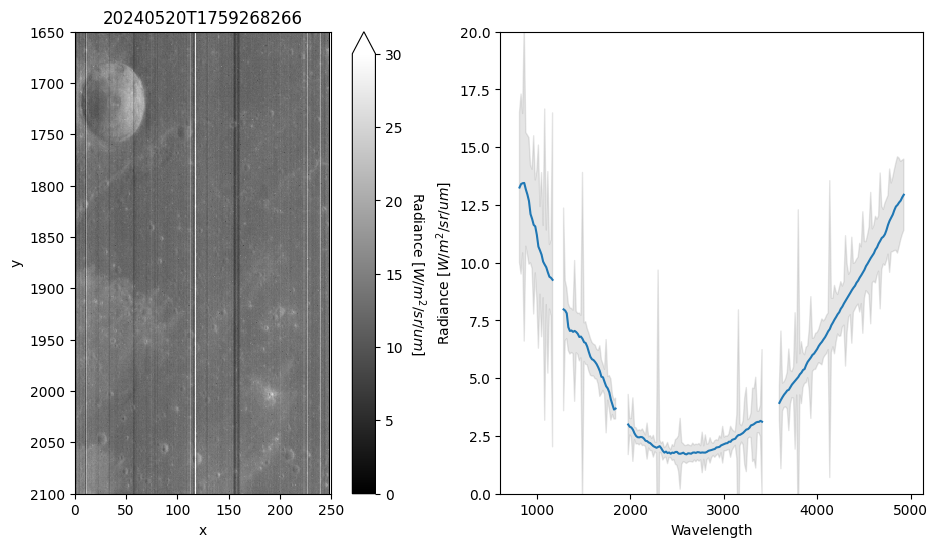

In [7]:
l1rad = l0_subset.calibrate()
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
l1rad.plot(ax=axs[0], vmax=30)
l1rad.plot_spectra(ax=axs[1])
axs[1].set_ylim(0, 20)

Verify this is similar to the published downloaded L1 data product

/home/cjtu/projects/iirspy/iirspy/utils.py:1458: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


(0.0, 20.0)

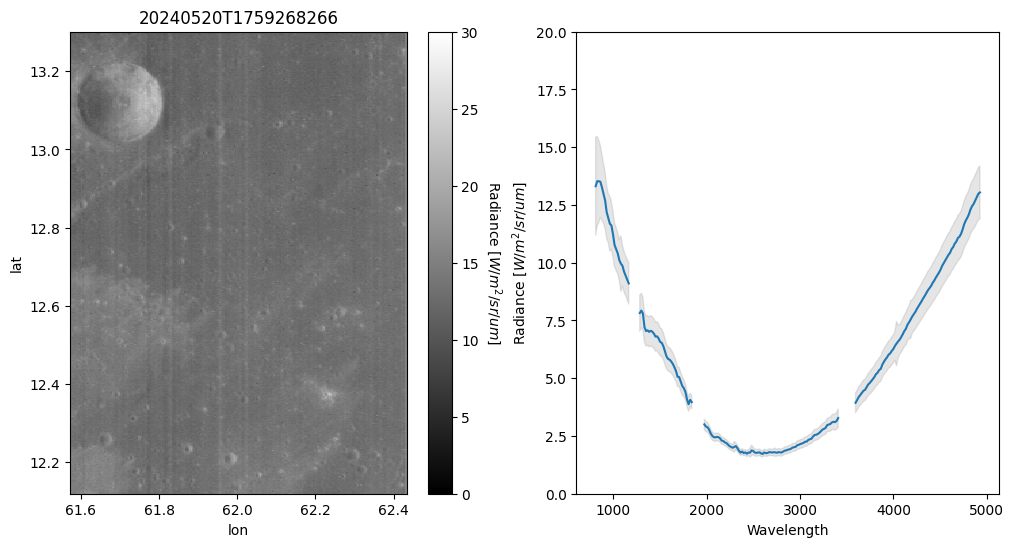

In [8]:
from iirspy import L1

l1_issdc = L1(im, ddir, xyextent=extent)
l1_issdc.mask_bad_bands()
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
l1_issdc.plot(ax=axs[0], vmax=30)
l1_issdc.plot_spectra(ax=axs[1])
axs[1].set_ylim(0, 20)

## Calibrate to reflectance

Similarly, l1 radiance can be calibrated to reflectance

In [9]:
from iirspy import L2

help(L2._compute_reflectance)

Help on function _compute_reflectance in module iirspy.iirs:

_compute_reflectance(self, rad, qub_path, csv_path, inc=None, dem=None, solar_flux=None, thermal_corr='')
    Compute I/f reflectance from radiance data and solar geometry.
    
    Optinally corrects for topographic effects and thermal correction.
    
    Parameters
    ----------
    rad : xarray.DataArray
        Radiance data array containing solar_inc, solar_az, and wl attributes.
    qub_path : str or None
        Path to QUB file for extracting solar distance. If None, assumes solar distance of 1.0 AU.
    csv_path : str
        Path to CSV file containing IIRS latitude/longitude information.
    inc : float or xarray.DataArray, optional
        Solar incidence angle in degrees. If None, extracted from rad coordinates.
    dem : xarray.DataArray or str, optional
        Digital elevation model as an xarray DataArray or path to DEM file.
        If provided, topographic effects are corrected using the DEM. Default is 

/home/cjtu/projects/iirspy/iirspy/utils.py:1458: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


<Axes: xlabel='Wavelength', ylabel='Reflectance'>

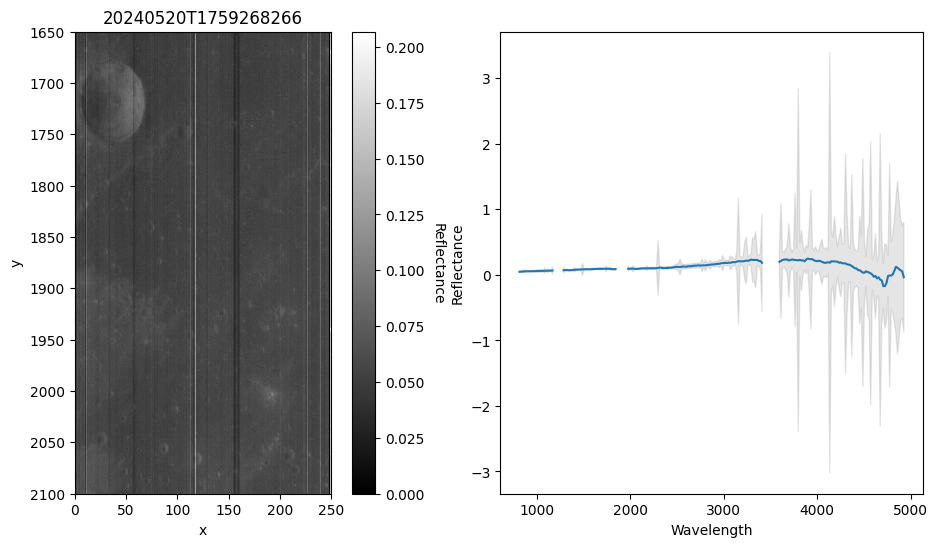

In [10]:
l2ref = l1rad.calibrate(inc=34.2, thermal_corr="verma")
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
l2ref.plot(ax=axs[0])
l2ref.plot_spectra(ax=axs[1])

## Gain and Offset Analysis

Here we analyze the gain and offset coefficients used for calibration. 

We can also naievely infer the true gain and offset values by fitting the published L0 and L1 data (after all postprocessing) and doing a linear fit as L1 = L0*gain + offset

In [11]:
import numpy as np
import xarray as xr
from scipy.stats import linregress

import iirspy.utils as utils
from iirspy import L0, L1


def new_linregress(x, y):
    # Filter NaNs to avoid stats issues
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) == 0 or (x < 1).all():
        return np.array([0, 0, 0, 1])

    slope, intercept, r_value, p_value, _ = linregress(x, y)
    out = np.array([slope, intercept, r_value, p_value])
    return out


def infer_gain_offset(l0, l1):
    """
    Return new gain and offset (band, x) from fits along y to L0 and L1 data.

    Assumes L1 = (L0 * gain) + offset.
    """
    # Parallize linregress, handles the multi outputs in new dim, param
    dn = l0.img.where(~l0.img.band.isin((*utils.OSF, *utils.INVALID)))
    rad = l1.img.where(~l1.img.band.isin((*utils.OSF, *utils.INVALID))) / 10
    stats = xr.apply_ufunc(
        new_linregress,
        dn,
        rad,
        input_core_dims=[["y"], ["y"]],
        output_core_dims=[["param"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=["float64"],
        output_sizes={"param": 4},
    )
    new_gain = stats.sel(param=0)
    new_offset = stats.sel(param=1)
    r_value = stats.sel(param=2)
    return new_gain, new_offset, r_value


im = "20240520T1759268266"
l0 = L0(im, ddir, extent=(0, 249, 1650, 2100))
l1 = L1(im, ddir, xyextent=(0, 249, 1650, 2100))
# l1 = l0.calibrate()  # Sanity check - should invert the gain offset applied directly in calibrate
# print(l0.img.shape, l1.img.shape)

# Infer gain and offset from the data and compute dask
new_gain, new_offset, r = infer_gain_offset(l0, l1)
new_gain = new_gain.compute()
new_offset = new_offset.compute()

# Load standard gain and offset
# gain_off_lut = utils.get_lut_file(l0.qub)
gain, offset = utils.get_gain_offset(l0.qub)
gain = gain.where(~gain.band.isin((*utils.OSF, *utils.INVALID))).fillna(0)[:, :249]
offset = offset.where(~offset.band.isin((*utils.OSF, *utils.INVALID))).fillna(0)[:, :249]

/tmp/ipykernel_303721/23740175.py:32: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  stats = xr.apply_ufunc(


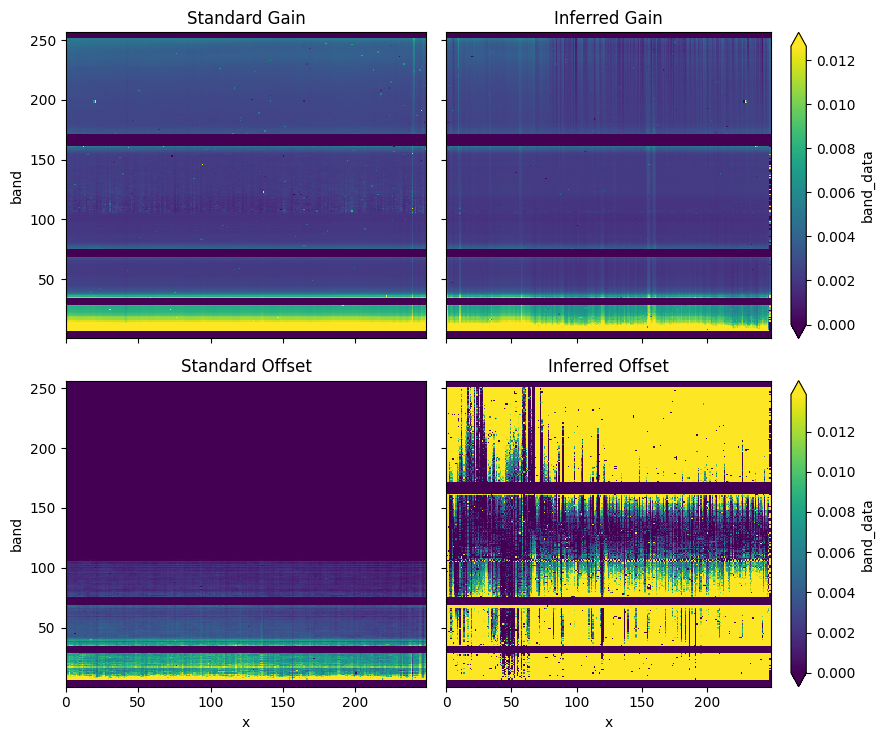

In [12]:
# Visualize Gain and Offset comparison
fig, axs = plt.subplots(2, 2, figsize=(9, 7.5), width_ratios=(0.89, 1), sharex=True, sharey=True)

gain.plot(vmin=gain.min(), vmax=gain.quantile(0.97), ax=axs[0, 0], add_colorbar=False)
axs[0, 0].set_title("Standard Gain")
new_gain.plot(vmin=gain.min(), vmax=gain.quantile(0.97), ax=axs[0, 1])
axs[0, 1].set_title("Inferred Gain")

offset.plot(vmin=offset.quantile(0.01), vmax=offset.quantile(0.99), ax=axs[1, 0], add_colorbar=False)
axs[1, 0].set_title("Standard Offset")
new_offset.plot(vmin=offset.quantile(0.01), vmax=offset.quantile(0.99), ax=axs[1, 1])
axs[1, 1].set_title("Inferred Offset")

fig.subplots_adjust(wspace=0.01, hspace=0.01)
axs[0, 1].set_ylabel("")
axs[1, 1].set_ylabel("")
axs[0, 0].set_xlabel("")
axs[0, 1].set_xlabel("")
plt.tight_layout()

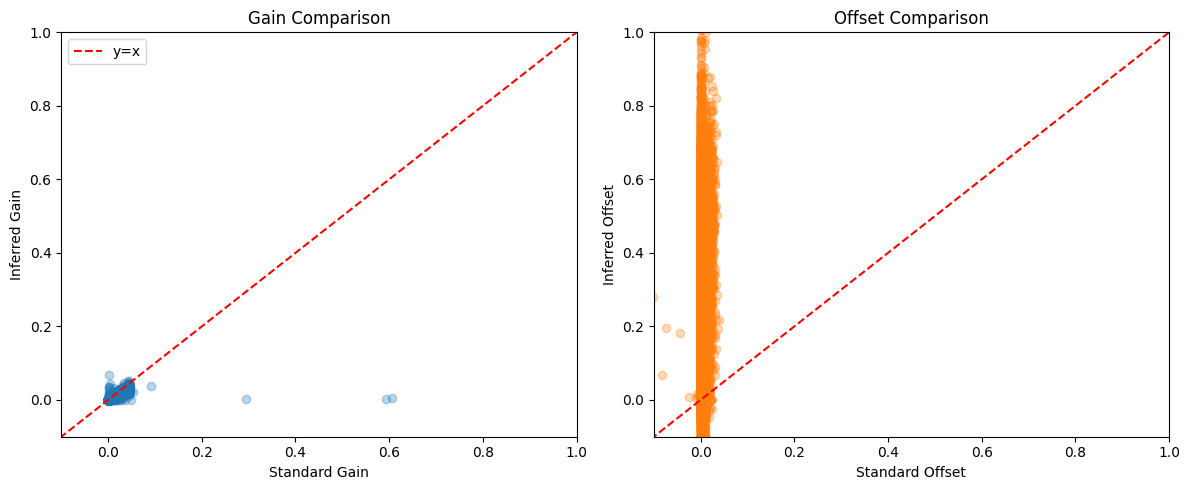

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gain comparison
axes[0].scatter(gain.values.flatten(), new_gain.values.flatten(), alpha=0.3)
axes[0].plot([-0.5, 3], [-0.5, 3], "r--", label="y=x")
axes[0].set_xlabel("Standard Gain")
axes[0].set_ylabel("Inferred Gain")
axes[0].set_title("Gain Comparison")
axes[0].legend()
axes[0].set_xlim(-0.1, 1)
axes[0].set_ylim(-0.1, 1)

# Offset comparison
axes[1].scatter(offset.values.flatten(), new_offset.values.flatten(), alpha=0.3, c="tab:orange")
axes[1].plot([-0.2, 3], [-0.2, 3], "r--", label="y=x")
axes[1].set_xlabel("Standard Offset")
axes[1].set_ylabel("Inferred Offset")
axes[1].set_title("Offset Comparison")
axes[1].set_xlim(-0.1, 1)
axes[1].set_ylim(-0.1, 1)

plt.tight_layout()

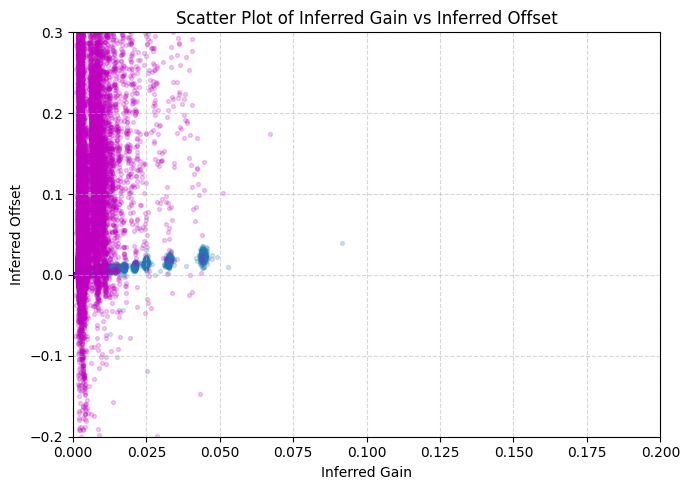

In [14]:
# Scatter plot of inferred gain vs inferred offset
plt.figure(figsize=(7, 5))
plt.scatter(gain.values.flatten(), offset.values.flatten(), alpha=0.2, s=8)
plt.scatter(new_gain.values.flatten(), new_offset.values.flatten(), alpha=0.2, s=8, c="m")
plt.xlabel("Inferred Gain")
plt.ylabel("Inferred Offset")
plt.title("Scatter Plot of Inferred Gain vs Inferred Offset")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(0, 0.2)
plt.ylim(-0.2, 0.3)
plt.tight_layout()
plt.show()

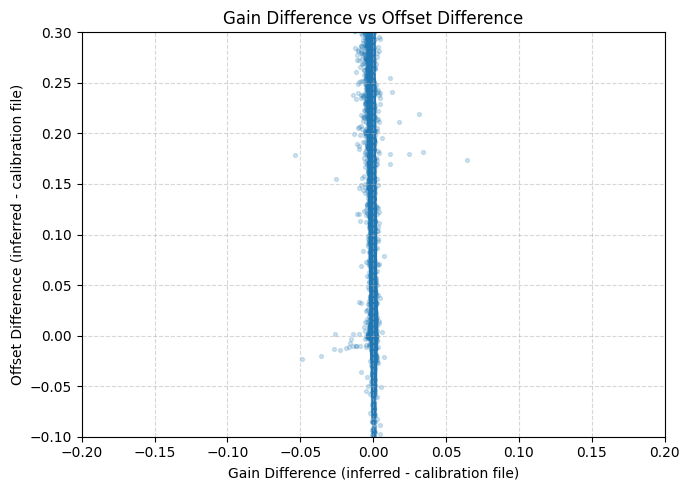

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(
    new_gain.values.flatten() - gain.values.flatten(),
    new_offset.values.flatten() - offset.values.flatten(),
    alpha=0.2,
    s=8,
)
plt.xlabel("Gain Difference (inferred - calibration file)")
plt.ylabel("Offset Difference (inferred - calibration file)")
plt.title("Gain Difference vs Offset Difference")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(-0.2, 0.2)
plt.ylim(-0.1, 0.3)
plt.tight_layout()
plt.show()